# Problem Title - Scratch Mode
Issue: #5

## 1. Setup and Imports
Use only NumPy and pandas for scratch work; do not use ML libraries unless the issue explicitly allows them.

In [10]:
import numpy as np
import pandas as pd

## 2. Load and Inspect Data
Load dataset.csv and validate shape, columns, and missing values before training.

In [ ]:
df = pd.read_csv("../dataset.csv")
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  quality_binary        6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


In [13]:
df.shape

(6497, 13)

In [14]:
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'quality_binary'],
      dtype='object')

In [15]:
# Choose the features and label
features = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol']

label = ['quality_binary']

In [16]:
X = df[features]
y = df[label]

X, y

(      fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
 0               7.4              0.70         0.00             1.9      0.076   
 1               7.8              0.88         0.00             2.6      0.098   
 2               7.8              0.76         0.04             2.3      0.092   
 3              11.2              0.28         0.56             1.9      0.075   
 4               7.4              0.70         0.00             1.9      0.076   
 ...             ...               ...          ...             ...        ...   
 6492            6.2              0.21         0.29             1.6      0.039   
 6493            6.6              0.32         0.36             8.0      0.047   
 6494            6.5              0.24         0.19             1.2      0.041   
 6495            5.5              0.29         0.30             1.1      0.022   
 6496            6.0              0.21         0.38             0.8      0.020   
 
       free_su

## 3. Preprocessing
Prepare features and target explicitly, including any normalization or encoding steps.

In [17]:
# Create a train test split function
def train_test_split(X, y, test_size=0.2):
  # this will check whether X, y is numpy array or not
  X_np = X.to_numpy() if hasattr(X, 'to_numpy') else X
  y_np = y.to_numpy() if hasattr(y, 'to_numpy') else y

  # Generate the indices
  num_samples = len(X_np)
  indices = np.arange(num_samples)

  # Shuffle the indices
  np.random.shuffle(indices)

  # gets the index to split the data
  split_idx = int(num_samples * (1 - test_size))

  # Split the indices to train and test
  train_indices = indices[:split_idx]
  test_indices = indices[split_idx:]

  # Split the data to train and test sets
  X_train, X_test = X_np[train_indices], X_np[test_indices]
  y_train, y_test = y_np[train_indices], y_np[test_indices]

  return X_train, X_test, y_train, y_test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X=X, y=y, test_size=0.2)
X_train[:5], X_test[:5], y_train[:5], y_test[:5]

(array([[7.6000e+00, 2.9000e-01, 2.6000e-01, 6.5000e+00, 4.2000e-02,
         3.2000e+01, 1.6000e+02, 9.9440e-01, 3.1400e+00, 4.7000e-01,
         1.0700e+01],
        [8.5000e+00, 1.6000e-01, 3.3000e-01, 1.0000e+00, 7.6000e-02,
         1.7000e+01, 5.7000e+01, 9.9210e-01, 3.1400e+00, 4.6000e-01,
         1.0600e+01],
        [6.8000e+00, 2.0000e-01, 3.8000e-01, 4.7000e+00, 4.0000e-02,
         2.7000e+01, 1.0300e+02, 9.9400e-01, 3.3700e+00, 5.8000e-01,
         1.0700e+01],
        [6.0000e+00, 3.6000e-01, 3.2000e-01, 1.1000e+00, 5.3000e-02,
         2.6000e+01, 1.7300e+02, 9.9414e-01, 3.3800e+00, 5.4000e-01,
         8.8000e+00],
        [6.5000e+00, 2.6000e-01, 3.9000e-01, 1.4000e+00, 2.0000e-02,
         1.2000e+01, 6.6000e+01, 9.9089e-01, 3.2500e+00, 7.5000e-01,
         1.1300e+01]]),
 array([[6.0000e+00, 3.0000e-01, 4.4000e-01, 1.5000e+00, 4.6000e-02,
         1.5000e+01, 1.8200e+02, 9.9455e-01, 3.5000e+00, 5.2000e-01,
         1.0400e+01],
        [6.3000e+00, 2.1000e-01, 5.800

In [35]:
# Create a custom dataloader
class CustomDataLoader:
    def __init__(self, X, y, batch_size=32, shuffle=True):
        self.X = X
        self.y = y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.n_samples = len(X)

        # Create an array of indices to keep track of where we are
        self.indices = np.arange(self.n_samples)

    def __iter__(self):
        # We shuffle the data at the start of every new epoch
        if self.shuffle:
            np.random.shuffle(self.indices)

        self.current_idx = 0  # Reset the counter
        return self

    def __next__(self):
        # This runs every time the loop asks for the next batch
        if self.current_idx >= self.n_samples:
            # If we've reached the end of the data, stop the loop
            raise StopIteration

        # Calculate where this batch ends
        end_idx = min(self.current_idx + self.batch_size, self.n_samples)

        # Grab the specific indices for this batch
        batch_indices = self.indices[self.current_idx : end_idx]

        # Extract the actual data
        X_batch = self.X[batch_indices]
        y_batch = self.y[batch_indices]

        # Move the pointer forward for the next time __next__ is called
        self.current_idx += self.batch_size

        return X_batch, y_batch

    def __len__(self):
        # returns the length of the dataloader when len(dataloader) is called
        return int(np.ceil(self.n_samples / self.batch_size))

In [36]:
BATCH_SIZE = 32

train_dataloader = CustomDataLoader(X=X_train,
                                    y=y_train,
                                    batch_size=BATCH_SIZE,
                                    shuffle=True)

test_dataloader = CustomDataLoader(X=X_test,
                                    y=y_test,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False)

train_dataloader, test_dataloader

(<__main__.CustomDataLoader at 0x7a2d752699a0>,
 <__main__.CustomDataLoader at 0x7a2d7526acf0>)

In [40]:
train_iter_obj = iter(train_dataloader)
test_iter_obj = iter(test_dataloader)
# batch_data = [next(train_iter_obj), next(iter_obj), next(iter_obj)]

batch_1 = next(train_iter_obj), next(test_iter_obj)
batch_2 = next(train_iter_obj), next(test_iter_obj)
batch_3 = next(train_iter_obj), next(test_iter_obj)

## 4. Algorithm Implementation
Implement core model logic from scratch and keep helper functions readable and testable.

In [20]:
# Createing the activation function(ReLU)
class Activation_ReLU:
    def forward(self, inputs):
      # Remember inputs for backpropagation
      self.inputs = inputs
      # This will return 0 if input < 0 and input if input >= 0
      self.output = np.maximum(0, inputs)

    def backward(self, dvalues):
      # Since we need to modify the original dvalues, let's make a copy
      self.dinputs = dvalues.copy()

      # ReLU derivative: If the original input was <= 0, the gradient is 0.
      # Otherwise, the gradient is 1 (so we just pass dvalues through unchanged).
      self.dinputs[self.inputs <= 0] = 0

In [21]:
# Createing the activation function(Sigmoid)
class Activation_Sigmoid:
    def forward(self, inputs):
      # Sigmoid math: 1 / (1 + e^-x)
      # We use np.clip to prevent overflow errors if inputs get too large
      clipped_inputs = np.clip(inputs, -500, 500)
      self.output = 1 / (1 + np.exp(-clipped_inputs))

    def backward(self, dvalues):
      # 1. Calculate the derivative of the Sigmoid function:
      #    derivative = output * (1 - output)
      derivative = self.output * (1.0 - self.output)

      # 2. Apply the Chain Rule!
      # Multiply our local derivative by the gradients passed backward (dvalues)
      self.dinputs = dvalues * derivative

In [22]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons):
      # Initialize weights with random values (scaled down to keep them small)
      # Shape is (inputs x neurons) so we don't have to transpose during the forward pass
      self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)

      # Initialize biases as a row vector of zeros
      self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
      # Remember inputs for backpropagation
      self.inputs = inputs
      # The core math of a neural network: Z = (X * W) + b
      # np.dot handles the matrix multiplication automatically
      self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
      # Gradients on parameters (This tells us how to update our weights/biases)
      self.dweights = np.dot(self.inputs.T, dvalues)
      self.dbiases = np.sum(dvalues, axis=0, keepdims=True)

      # Gradient on values (This is passed backward to the previous layer)
      self.dinputs = np.dot(dvalues, self.weights.T)

In [23]:
class Optimizer_SGD:
    def __init__(self, lr=0.01):
      self.learning_rate = lr

    def update_params(self, layer):
      # Move the weights in the opposite direction of the gradient
      layer.weights -= self.learning_rate * layer.dweights
      layer.biases -= self.learning_rate * layer.dbiases

In [24]:
# BinaryCrossEntropyLoss
# -(y * log(p) + (1-y) * log(1-p))
# y - true label, p - prediction probability
class BCELoss:
  def forward(self, y_pred, y_true):
    # 1. Clip data to prevent division by 0 and infinity errors
    # We cap predictions between a tiny number (1e-7) and slightly less than 1
    self.y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)
    self.y_true = y_true

    # 2. Calculate sample-wise loss using the BCE formula
    sample_losses = -(self.y_true * np.log(self.y_pred_clipped) + (1 - self.y_true) * np.log(1 - self.y_pred_clipped))

    # 3. Return the mean loss for the batch
    return np.mean(sample_losses)

  def backward(self):
    # Number of samples in the batch
    # samples = len(y_pred)

    # 1. Clip data (same as forward pass)
    # y_pred_clipped = np.clip(y_pred, 1e-7, 1 - 1e-7)

    # 2. Calculate the gradient (derivative of BCE)
    # This formula is derived using the chain rule on the BCE equation
    self.dinputs = -(self.y_true / self.y_pred_clipped - (1 - self.y_true) / (1 - self.y_pred_clipped))

    # 3. Normalize the gradient by dividing by the batch size
    self.dinputs = self.dinputs / len(self.y_pred_clipped)

In [25]:
def accuracy_fn(y_pred, y_true):
  cnt_true = 0
  for i, y in enumerate(y_pred):
    if y == y_true[i]: cnt_true += 1
  return cnt_true / len(y_pred)

## 5. Training
Train your scratch implementation and track learning behavior across iterations.

In [34]:
input_shape = X_train.shape[1]
output_shape = 1 # for binary classification output_shape is 1 only
input_shape, output_shape

(11, 1)

In [59]:
def test_backprop(X_train, X_test, y_train, y_test):
  HIDDEN_UNITS = 10
  # Initializing layers and activation function
  layer_1 = Layer_Dense(n_inputs=input_shape,
                        n_neurons=HIDDEN_UNITS)
  relu_1 = Activation_ReLU()
  layer_2 = Layer_Dense(n_inputs=HIDDEN_UNITS,
                        n_neurons=output_shape)
  sigmoid_1 = Activation_Sigmoid()

  # Setting up the loss function and optimizer
  loss_fn = BCELoss()
  optimizer = Optimizer_SGD(lr=0.01)

  # Training Loop for small batch
  epochs = 10

  results = []

  for epoch in range(epochs):

    layer_1.forward(X_train)
    relu_1.forward(layer_1.output)
    layer_2.forward(relu_1.output)
    sigmoid_1.forward(layer_2.output)

    y_pred = sigmoid_1.output

    # Calculate the loss
    train_loss = loss_fn.forward(y_pred=y_pred, y_true=y_train)
    train_accuracy = accuracy_fn(y_pred=y_pred.round(), y_true=y_train)

    # Backward pass
    loss_fn.backward()
    sigmoid_1.backward(loss_fn.dinputs)
    layer_2.backward(sigmoid_1.dinputs)
    relu_1.backward(layer_2.dinputs)
    layer_1.backward(relu_1.dinputs)

    # Optimezer step (Gradient Descent)
    optimizer.update_params(layer=layer_1)
    optimizer.update_params(layer=layer_2)

    # train_loss /= len(X_train)
    # train_accuracy /= len(X_train)

    # Testing
    # Forward pass
    layer_1.forward(X_test)
    relu_1.forward(layer_1.output)
    layer_2.forward(relu_1.output)
    sigmoid_1.forward(layer_2.output)

    y_pred = sigmoid_1.output

    # Calculate the loss
    test_loss = loss_fn.forward(y_pred=y_pred, y_true=y_test)
    test_accuracy = accuracy_fn(y_pred=y_pred.round(), y_true=y_test)

    # test_loss /= len(X_test)
    # test_accuracy /= len(X_test)

    epoch_count.append(epoch)
    print(f"Epoch: {epoch}\n------------")
    print(f"Loss: {train_loss:.3f} | Test Loss: {test_loss:.3f}")
    print(f"Accuracy: {(train_accuracy*100):.2f}% | Test Accuracy: {(test_accuracy*100):.2f}%\n")

    results.append({"train_loss": train_loss,
                    "train_accuracy": train_accuracy*100,
                    "test_loss": test_loss,
                    "test_accuracy": test_accuracy*100})

  return results

In [60]:
results_1 = test_backprop(X_train=batch_1[0][0], X_test=batch_1[1][0], y_train=batch_1[0][1], y_test=batch_1[1][1])

Epoch: 0
------------
Loss: 0.677 | Test Loss: 0.632
Accuracy: 62.50% | Test Accuracy: 68.75%

Epoch: 1
------------
Loss: 0.677 | Test Loss: 0.635
Accuracy: 62.50% | Test Accuracy: 71.88%

Epoch: 2
------------
Loss: 0.676 | Test Loss: 0.629
Accuracy: 62.50% | Test Accuracy: 71.88%

Epoch: 3
------------
Loss: 0.675 | Test Loss: 0.630
Accuracy: 62.50% | Test Accuracy: 75.00%

Epoch: 4
------------
Loss: 0.674 | Test Loss: 0.625
Accuracy: 62.50% | Test Accuracy: 75.00%

Epoch: 5
------------
Loss: 0.669 | Test Loss: 0.626
Accuracy: 62.50% | Test Accuracy: 75.00%

Epoch: 6
------------
Loss: 0.668 | Test Loss: 0.618
Accuracy: 62.50% | Test Accuracy: 71.88%

Epoch: 7
------------
Loss: 0.669 | Test Loss: 0.634
Accuracy: 62.50% | Test Accuracy: 78.12%

Epoch: 8
------------
Loss: 0.670 | Test Loss: 0.613
Accuracy: 68.75% | Test Accuracy: 68.75%

Epoch: 9
------------
Loss: 0.670 | Test Loss: 0.638
Accuracy: 59.38% | Test Accuracy: 78.12%



In [61]:
results_2 = test_backprop(X_train=batch_2[0][0], X_test=batch_2[1][0], y_train=batch_2[0][1], y_test=batch_2[1][1])

Epoch: 0
------------
Loss: 0.589 | Test Loss: 0.544
Accuracy: 62.50% | Test Accuracy: 87.50%

Epoch: 1
------------
Loss: 0.677 | Test Loss: 0.433
Accuracy: 84.38% | Test Accuracy: 87.50%

Epoch: 2
------------
Loss: 0.525 | Test Loss: 0.425
Accuracy: 84.38% | Test Accuracy: 87.50%

Epoch: 3
------------
Loss: 0.528 | Test Loss: 0.438
Accuracy: 84.38% | Test Accuracy: 87.50%

Epoch: 4
------------
Loss: 0.523 | Test Loss: 0.430
Accuracy: 84.38% | Test Accuracy: 87.50%

Epoch: 5
------------
Loss: 0.533 | Test Loss: 0.438
Accuracy: 84.38% | Test Accuracy: 87.50%

Epoch: 6
------------
Loss: 0.521 | Test Loss: 0.426
Accuracy: 84.38% | Test Accuracy: 87.50%

Epoch: 7
------------
Loss: 0.525 | Test Loss: 0.429
Accuracy: 84.38% | Test Accuracy: 87.50%

Epoch: 8
------------
Loss: 0.506 | Test Loss: 0.409
Accuracy: 84.38% | Test Accuracy: 87.50%

Epoch: 9
------------
Loss: 0.506 | Test Loss: 0.413
Accuracy: 84.38% | Test Accuracy: 87.50%



In [62]:
results_3 = test_backprop(X_train=batch_3[0][0], X_test=batch_3[1][0], y_train=batch_3[0][1], y_test=batch_3[1][1])

Epoch: 0
------------
Loss: 0.690 | Test Loss: 0.575
Accuracy: 59.38% | Test Accuracy: 78.12%

Epoch: 1
------------
Loss: 0.693 | Test Loss: 0.747
Accuracy: 59.38% | Test Accuracy: 25.00%

Epoch: 2
------------
Loss: 0.711 | Test Loss: 0.564
Accuracy: 34.38% | Test Accuracy: 75.00%

Epoch: 3
------------
Loss: 0.796 | Test Loss: 1.426
Accuracy: 65.62% | Test Accuracy: 25.00%

Epoch: 4
------------
Loss: 0.972 | Test Loss: 0.795
Accuracy: 34.38% | Test Accuracy: 75.00%

Epoch: 5
------------
Loss: 1.167 | Test Loss: 1.117
Accuracy: 65.62% | Test Accuracy: 25.00%

Epoch: 6
------------
Loss: 0.826 | Test Loss: 0.561
Accuracy: 34.38% | Test Accuracy: 75.00%

Epoch: 7
------------
Loss: 0.791 | Test Loss: 0.826
Accuracy: 65.62% | Test Accuracy: 28.12%

Epoch: 8
------------
Loss: 0.714 | Test Loss: 0.558
Accuracy: 40.62% | Test Accuracy: 75.00%

Epoch: 9
------------
Loss: 0.693 | Test Loss: 0.689
Accuracy: 59.38% | Test Accuracy: 56.25%



## 6. Evaluation
Report the correct metric clearly and compare achieved value with target threshold.

In [64]:
results = [results_1, results_2, results_3]

In [65]:
metrics = []

for result in results:
  train_loss_list = []
  test_loss_list = []
  train_accuracy_list = []
  test_accuracy_list = []
  for r in result:
    train_loss_list.append(r["train_loss"])
    test_loss_list.append(r["test_loss"])
    train_accuracy_list.append(r["train_accuracy"])
    test_accuracy_list.append(r["test_accuracy"])

  metrics.append((train_loss_list, test_loss_list, train_accuracy_list, test_accuracy_list))


In [66]:
import matplotlib.pyplot as plt

def plot_loss_accuracy(epoch_count_list: list[int],
                       train_loss_list: list[float],
                       test_loss_list: list[float],
                       train_accuracy_list: list[float],
                       test_accuracy_list: list[float],
                       model_name: str = ""):
  # Loss Curve
  plt.figure(figsize=(12, 5))
  plt.subplot(1, 2, 1)
  plt.plot(epoch_count_list, train_loss_list, 'r', label='Training Loss')
  plt.plot(epoch_count_list, test_loss_list, 'b', label='Validation Loss')
  plt.title(f'{model_name} Model Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()

  # Accuracy Curve
  plt.subplot(1, 2, 2)
  plt.plot(epoch_count_list, train_accuracy_list, 'r', label='Training Accuracy')
  plt.plot(epoch_count_list, test_accuracy_list, 'b', label='Validation Accuracy')
  plt.title(f'{model_name} Model Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()

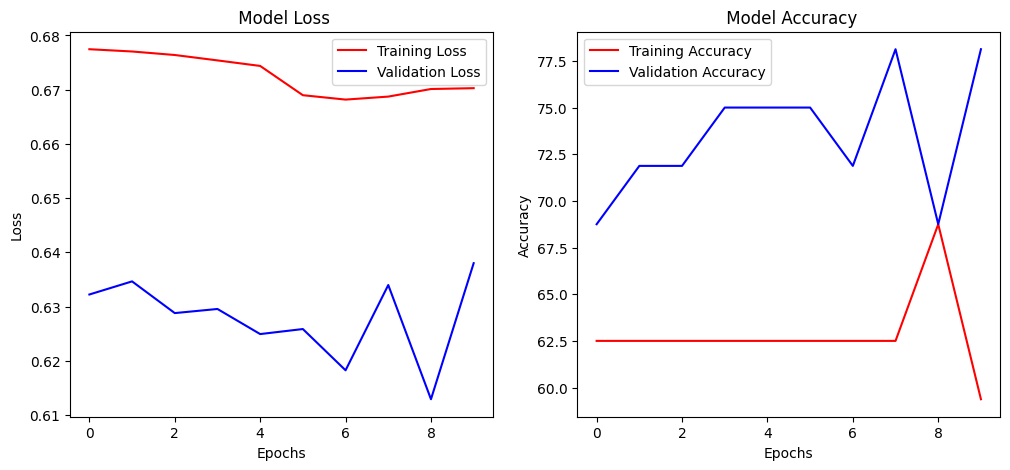

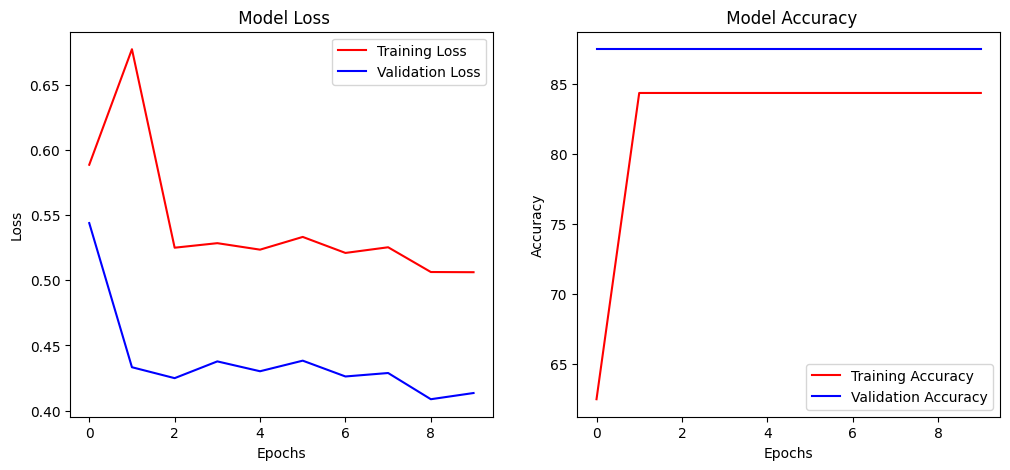

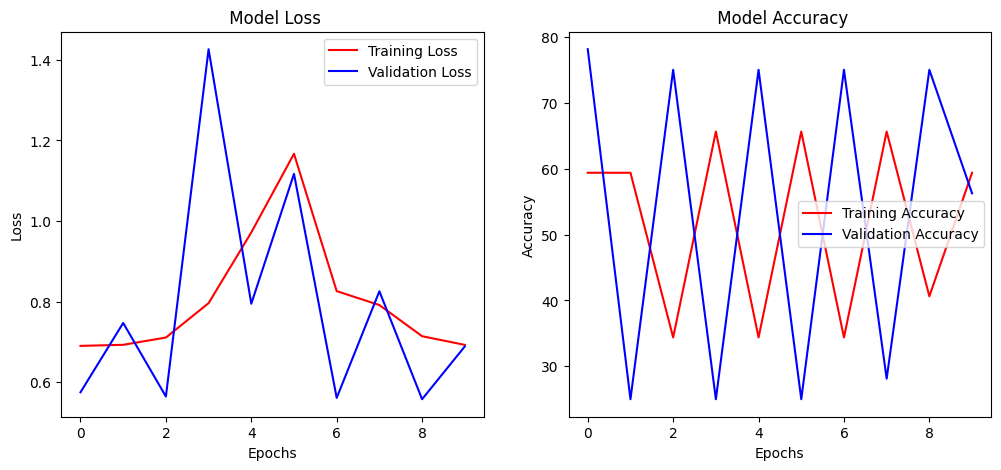

In [68]:
plot_loss_accuracy(epoch_count_list=range(10),
                   train_loss_list=metrics[0][0],
                   test_loss_list=metrics[0][1],
                   train_accuracy_list=metrics[0][2],
                   test_accuracy_list=metrics[0][3])

plot_loss_accuracy(epoch_count_list=range(10),
                   train_loss_list=metrics[1][0],
                   test_loss_list=metrics[1][1],
                   train_accuracy_list=metrics[1][2],
                   test_accuracy_list=metrics[1][3])

plot_loss_accuracy(epoch_count_list=range(10),
                   train_loss_list=metrics[2][0],
                   test_loss_list=metrics[2][1],
                   train_accuracy_list=metrics[2][2],
                   test_accuracy_list=metrics[2][3])

## 7. Summary
Answer only these scratch-training questions:
1. Which core steps did you implement from scratch (math + code)?
2. How did your training behavior change over iterations (loss/metric trend), and what explains it?
3. What have you learned from implementing and evaluating this model from scratch in this notebook?

1. Createion to the activation functions, optimizer, Dense Layer class and Loss function. The math was done with the help of numpy.

2. The loss is going down and the accuracy is going up so the neural net is actually learning(which means the weights and biases are bweing updated)
3. I have learn about how all the different function connects and how everything works behind the scene in Pytorch and Tensorflow.